In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras import Input
from tensorflow.keras.optimizers import Adam

In [ ]:
import os
import json
from getpass import getpass

# Enter Kaggle credentials securely
# KAGGLE_USERNAME = input("Enter your Kaggle username: ")
# KAGGLE_KEY = getpass("Enter your Kaggle API token: ")

# Create Kaggle config directory
os.makedirs("/root/.kaggle", exist_ok=True)

# Save credentials to kaggle.json
with open("/root/.kaggle/kaggle.json", "w") as f:
    json.dump({
        "username": "sonusurendran",
        "key": "KGAT_a153b4de8a11ce2f119dc08d7d717821"
    }, f)

    !chmod 600 /root/.kaggle/kaggle.json

In [ ]:
import os

DATASET_NAME = "olafkrastovski/handwritten-digits-0-9"
SAVE_DIR = "/content/image"

os.makedirs(SAVE_DIR, exist_ok=True)

# Download and unzip dataset into /content/image
!kaggle datasets download -d {DATASET_NAME} -p {SAVE_DIR} --unzip

print("Dataset downloaded and saved to:", SAVE_DIR)

Dataset URL: https://www.kaggle.com/datasets/olafkrastovski/handwritten-digits-0-9
License(s): CC0-1.0
100% 66.7M/66.7M [00:00<00:00, 182MB/s]

Dataset downloaded and saved to: /content/image


In [ ]:
import os
import numpy as np
from PIL import Image

DATA_DIR = "/content/image"
IMG_SIZE = (28, 28)

X = []
y = []

class_names = sorted([
    folder for folder in os.listdir(DATA_DIR)
    if os.path.isdir(os.path.join(DATA_DIR, folder))
])

print("Classes:", class_names)

for class_name in class_names:
    class_folder = os.path.join(DATA_DIR, class_name)

    for file_name in os.listdir(class_folder):
        file_path = os.path.join(class_folder, file_name)

        try:
            img = Image.open(file_path).convert("L")
            img = img.resize(IMG_SIZE)

            img_array = np.array(img)

            X.append(img_array)
            y.append(int(class_name))   # label comes from folder name

        except Exception as e:
            print("Skipped:", file_path, e)

X = np.array(X).astype("float32") / 255.0
y = np.array(y).astype("int32")

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Labels:", np.unique(y, return_counts=True))

Classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
X shape: (21555, 28, 28)
y shape: (21555,)
Labels: (array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=int32), array([2236, 2241, 2233, 2202, 2179, 2126, 2121, 2116, 2085, 2016]))


In [ ]:
X = 1-X #important to train the model, because with white background the accuracy is low
x_train_flat= X.reshape(X.shape[0], 28 * 28)

idx = np.random.permutation(len(x_train_flat))

x_train = x_train_flat[idx]
y_train = y[idx]

print("Data reshuffled. Verifying first label:", y_train[0])

Data reshuffled. Verifying first label: 1


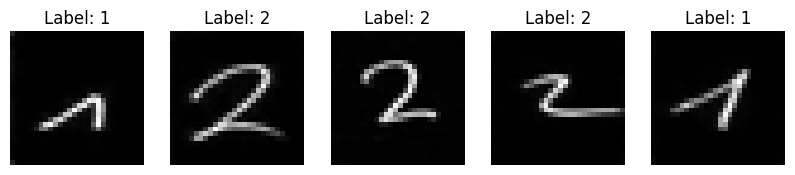

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 2))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.show()

In [ ]:
model = Sequential ([
    Dense(units=128, activation="relu", input_shape=(784,), name="layer1"),
    Dense(units=64, activation="relu", name="layer2"),
    Dense(units=10, activation="linear", name="output")
])

In [ ]:
model.compile(
    loss = SparseCategoricalCrossentropy(from_logits=True),
    optimizer = Adam(learning_rate = 0.001),
    metrics=["accuracy"]
)

In [ ]:

model.fit(x_train, y_train, epochs=20, batch_size=32)

Epoch 1/20
674/674 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9930 - loss: 0.0225
Epoch 2/20
674/674 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9915 - loss: 0.0262
Epoch 3/20
674/674 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9889 - loss: 0.0351
Epoch 4/20
674/674 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9920 - loss: 0.0244
Epoch 5/20
674/674 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9913 - loss: 0.0267
Epoch 6/20
674/674 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9942 - loss: 0.0194
Epoch 7/20
674/674 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9972 - loss: 0.0107
Epoch 8/20
674/674 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9975 - loss: 0.0086
Epoch 9/20
674/674 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9946 - loss: 0.0168
Epoch 10/20
674/674 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9812 - loss: 0.0570
Epoch 11/20
674/674 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9940 - loss: 0.0181
Epoch 12/20
674/674 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step

In [ ]:
yhat = model.predict(x_train)

674/674 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


In [ ]:
yhat

array([[ -8.816947 ,  13.196151 ,  -9.931189 , ...,  -1.8908225,
         -2.0095985,  -9.885195 ],
       [  0.4211297, -22.071033 ,  28.879955 , ...,  -6.335761 ,
         -5.381922 , -11.040423 ],
       [-11.7450905, -34.398144 ,  18.547287 , ...,   2.9644601,
          8.55895  , -19.00685  ],
       ...,
       [ -3.0643792, -21.166636 ,  -3.8286664, ...,  -6.4064274,
         13.045057 ,   0.9786681],
       [  8.370161 ,  41.15988  , -13.215271 , ..., -32.130566 ,
         -7.5615087,  -5.3672233],
       [ -4.230396 , -26.174837 , -13.736355 , ..., -16.756495 ,
         -5.071002 ,  21.50842  ]], dtype=float32)

In [ ]:
ypred = tf.nn.softmax(yhat, axis=1).numpy()
probs = np.argmax(ypred, axis=1)

In [ ]:
probs

array([1, 2, 2, ..., 8, 1, 9])

In [ ]:
np.mean(probs == y_train)

np.float64(0.9976803525864069)

In [ ]:
y

array([4, 5, 3, ..., 9, 2, 2])

In [ ]:
mis = np.zeros(len(y))

mis = (y != probs).astype(int)

In [ ]:
np.mean(y == probs)

np.float64(0.40143818139642773)

In [ ]:
np.unique(y)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [ ]:
model.summary(0)

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ layer1 (Dense)                  │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer2 (Dense)                  │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 328,160 (1.25 MB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 218,774 (854.59 KB)

In [ ]:
probs.shape

(21555,)

In [ ]:
ypred.shape

(21555, 10)

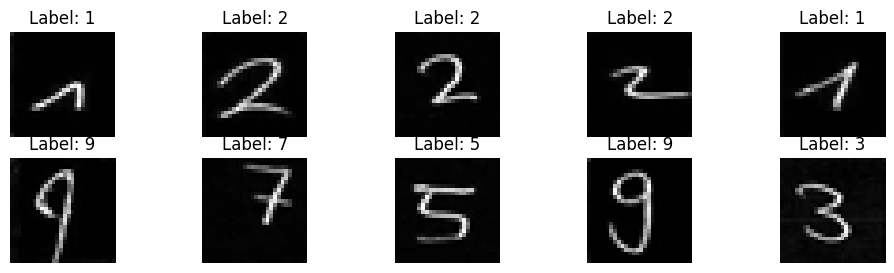

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 3))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.show()